In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('final_df.csv')
df['Date_Match'] = pd.to_datetime(df['Date_Match'])
df.head()

,NakhonPathom_Meat_Temperature_C,PathumThani_Hub_Temperature_C,Phetchabun_High_Temperature_C,Ratchaburi_Veg_Temperature_C,NakhonPathom_Meat_Rainfall_mm,PathumThani_Hub_Rainfall_mm,Phetchabun_High_Rainfall_mm,Ratchaburi_Veg_Rainfall_mm,NakhonPathom_Meat_Humidity_Percent,PathumThani_Hub_Humidity_Percent,...,Price_garlic,Price_lime,Price_onion,Price_peanut,Price_pork,Price_shallot,Price_shrimp,Price_spring_onion,Price_tamarind_juice,Important_Days
0,22.12,22.08,19.99,21.70,0.0,0.0,0.0,0.0,50.83,52.29,...,82.5,2.25,35.0,70.0,162.5,105.0,225.0,85.0,95.0,1
1,22.67,22.73,19.56,22.27,0.0,0.0,0.0,0.0,52.29,52.92,...,82.5,2.25,35.0,70.0,162.5,105.0,225.0,85.0,95.0,0
2,23.85,24.00,21.00,23.27,0.0,0.0,0.0,0.0,54.88,56.33,...,82.5,2.25,35.0,70.0,162.5,105.0,225.0,85.0,95.0,0
3,25.20,25.47,23.21,24.61,0.0,0.0,0.0,0.0,57.83,58.04,...,82.5,2.25,35.0,70.0,162.5,105.0,225.0,85.0,95.0,0
4,26.45,26.65,24.98,25.99,0.0,0.0,0.0,0.0,60.62,58.83,...,82.5,2.25,35.0,70.0,162.5,105.0,225.0,85.0,95.0,0


In [4]:
cols_to_drop = ['Day', 'Month', 'Year', 'Date_Match']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.describe().T[['mean', 'std', 'min', '50%', 'max']]


,mean,std,min,50%,max
NakhonPathom_Meat_Temperature_C,27.894412,2.029166,20.320,27.80,34.02
PathumThani_Hub_Temperature_C,27.888456,1.844440,20.640,27.79,33.74
Phetchabun_High_Temperature_C,27.055857,2.243839,18.770,27.15,34.02
Ratchaburi_Veg_Temperature_C,27.784959,2.141508,20.200,27.74,34.17
NakhonPathom_Meat_Rainfall_mm,4.553968,7.123215,0.000,1.10,57.50
PathumThani_Hub_Rainfall_mm,5.217406,8.053799,0.000,1.30,67.50
Phetchabun_High_Rainfall_mm,4.985057,8.965976,0.000,0.60,99.50
Ratchaburi_Veg_Rainfall_mm,4.092830,6.528083,0.000,0.90,55.10
NakhonPathom_Meat_Humidity_Percent,73.385961,9.715722,47.000,73.67,94.21
PathumThani_Hub_Humidity_Percent,73.961270,10.882801,43.920,75.62,94.62


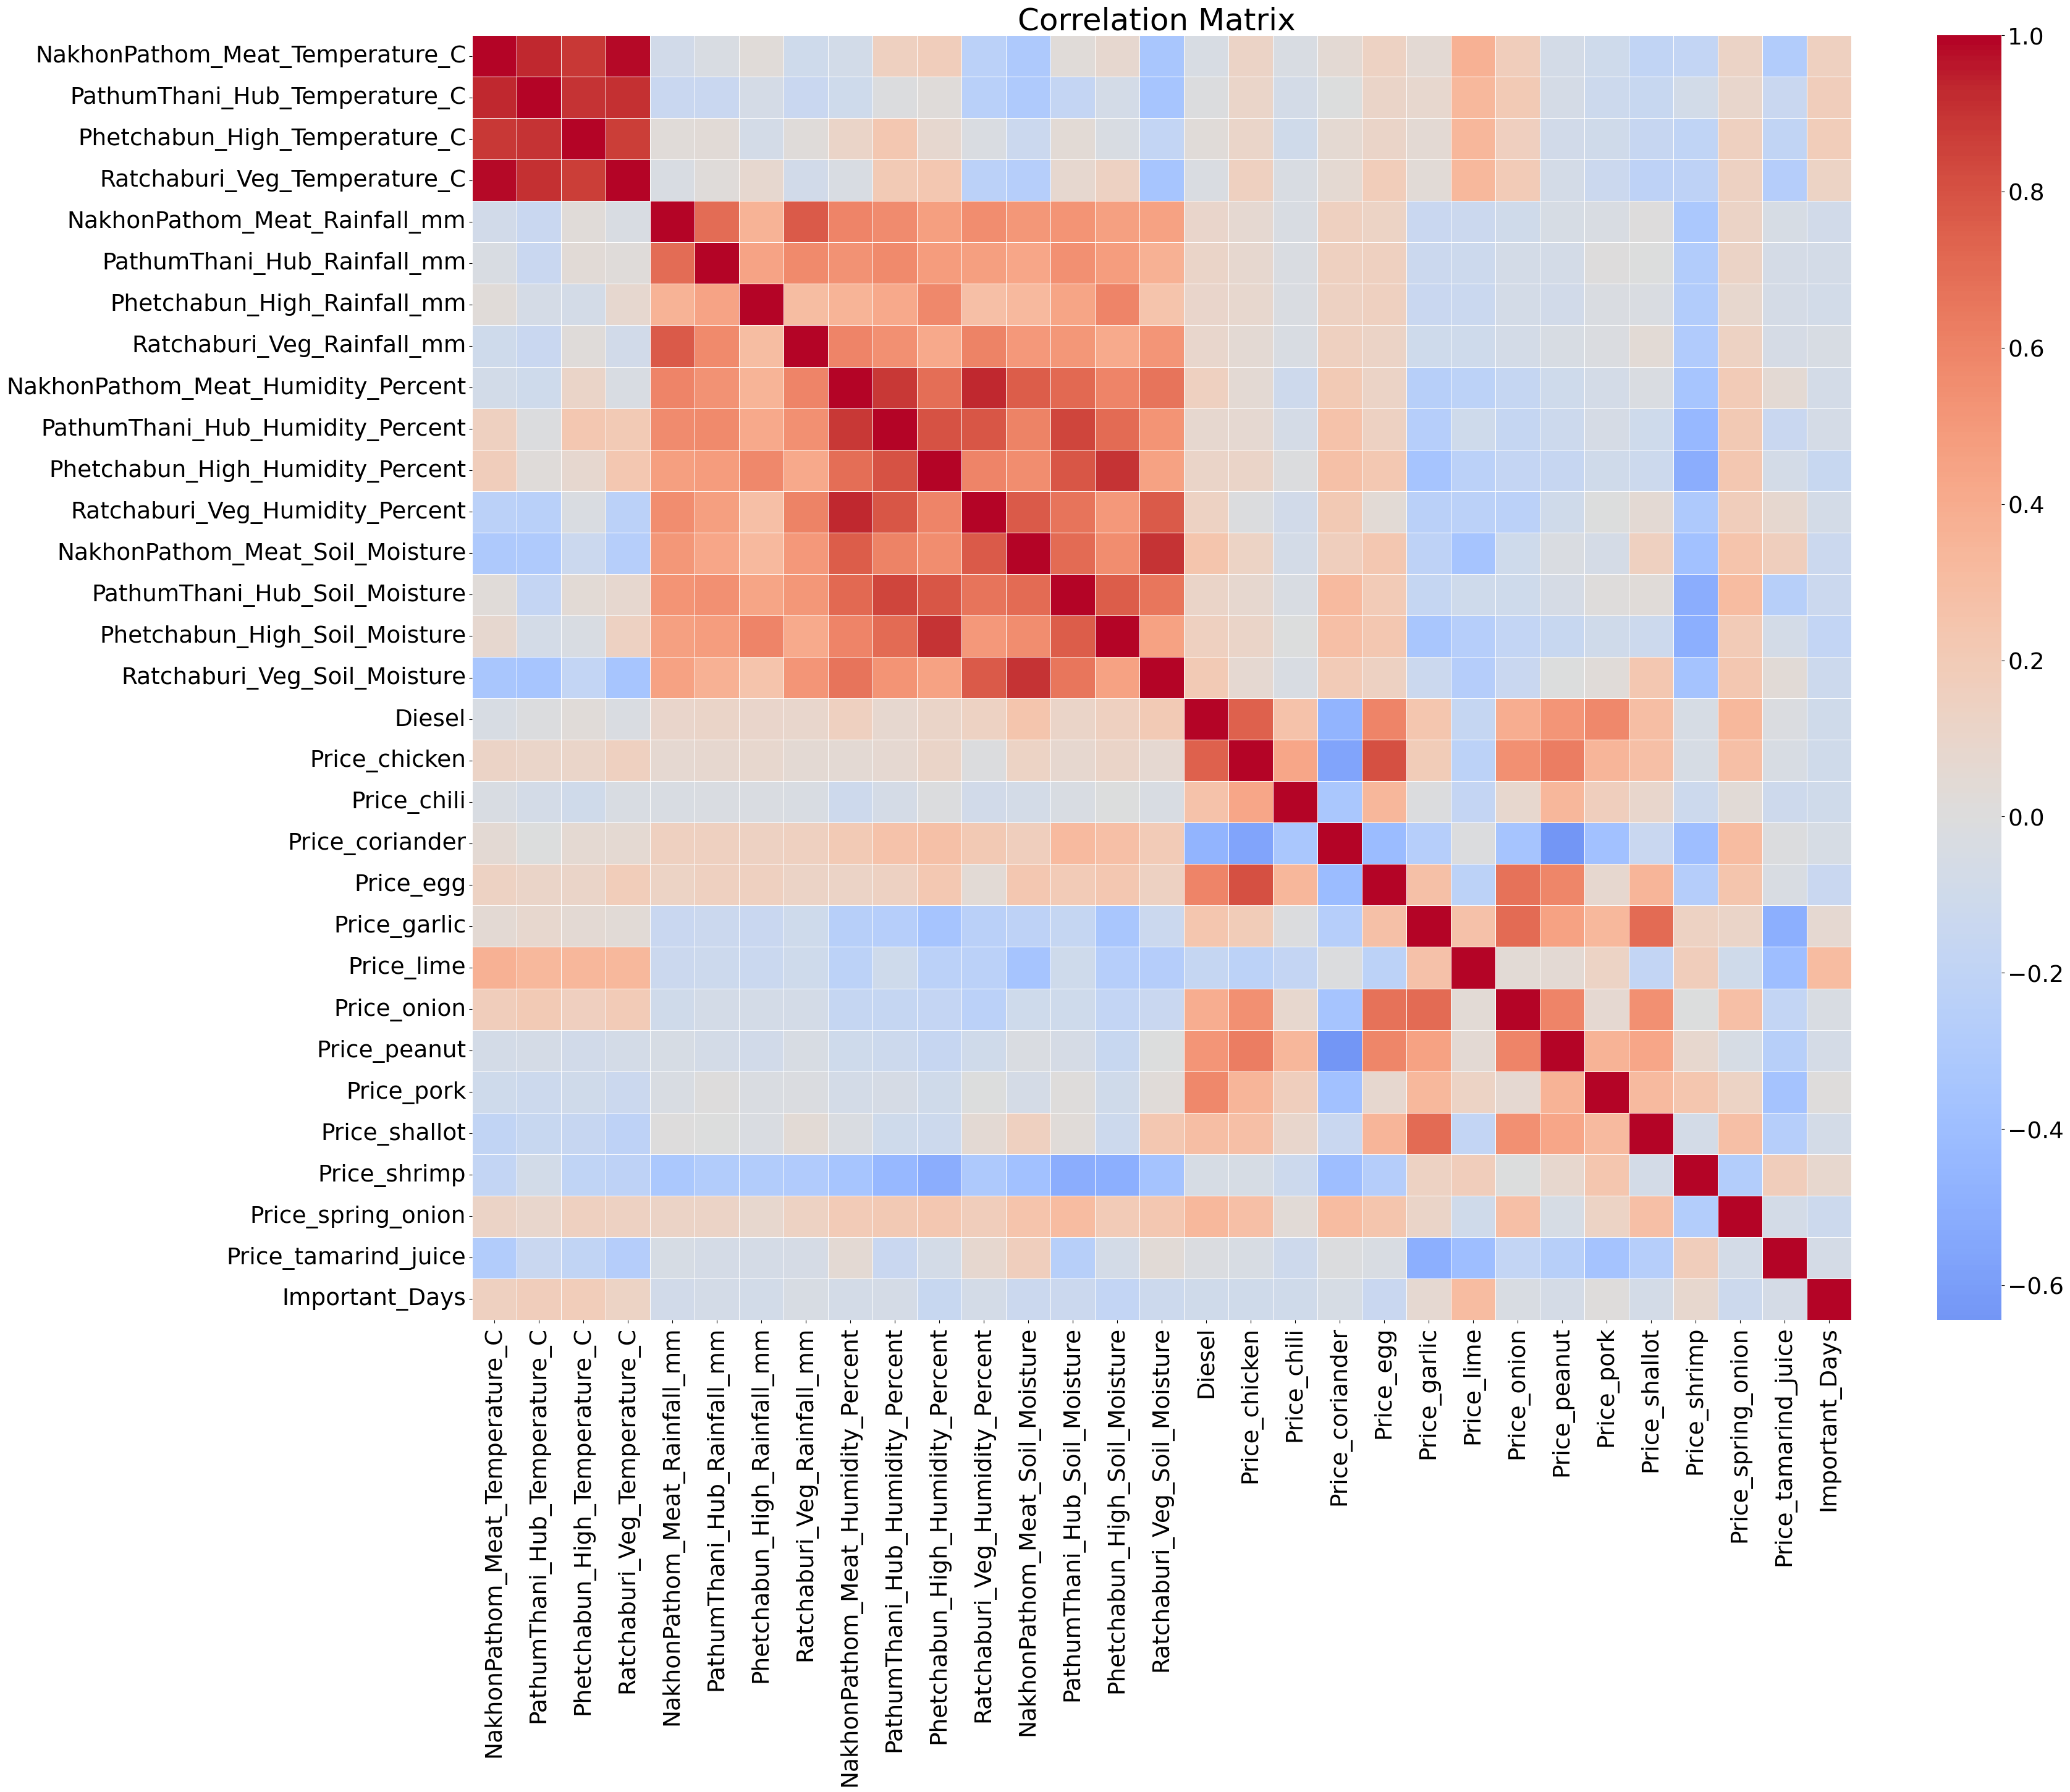

In [ ]:
plt.figure(figsize=(36, 27))
correlation = df_analysis.corr()

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 27

sns.heatmap(correlation, 
            annot=False,
            cmap='coolwarm', 
            center=0,
            linewidths=0.5)
plt.title('Correlation Matrix ', fontsize=36)
plt.show()




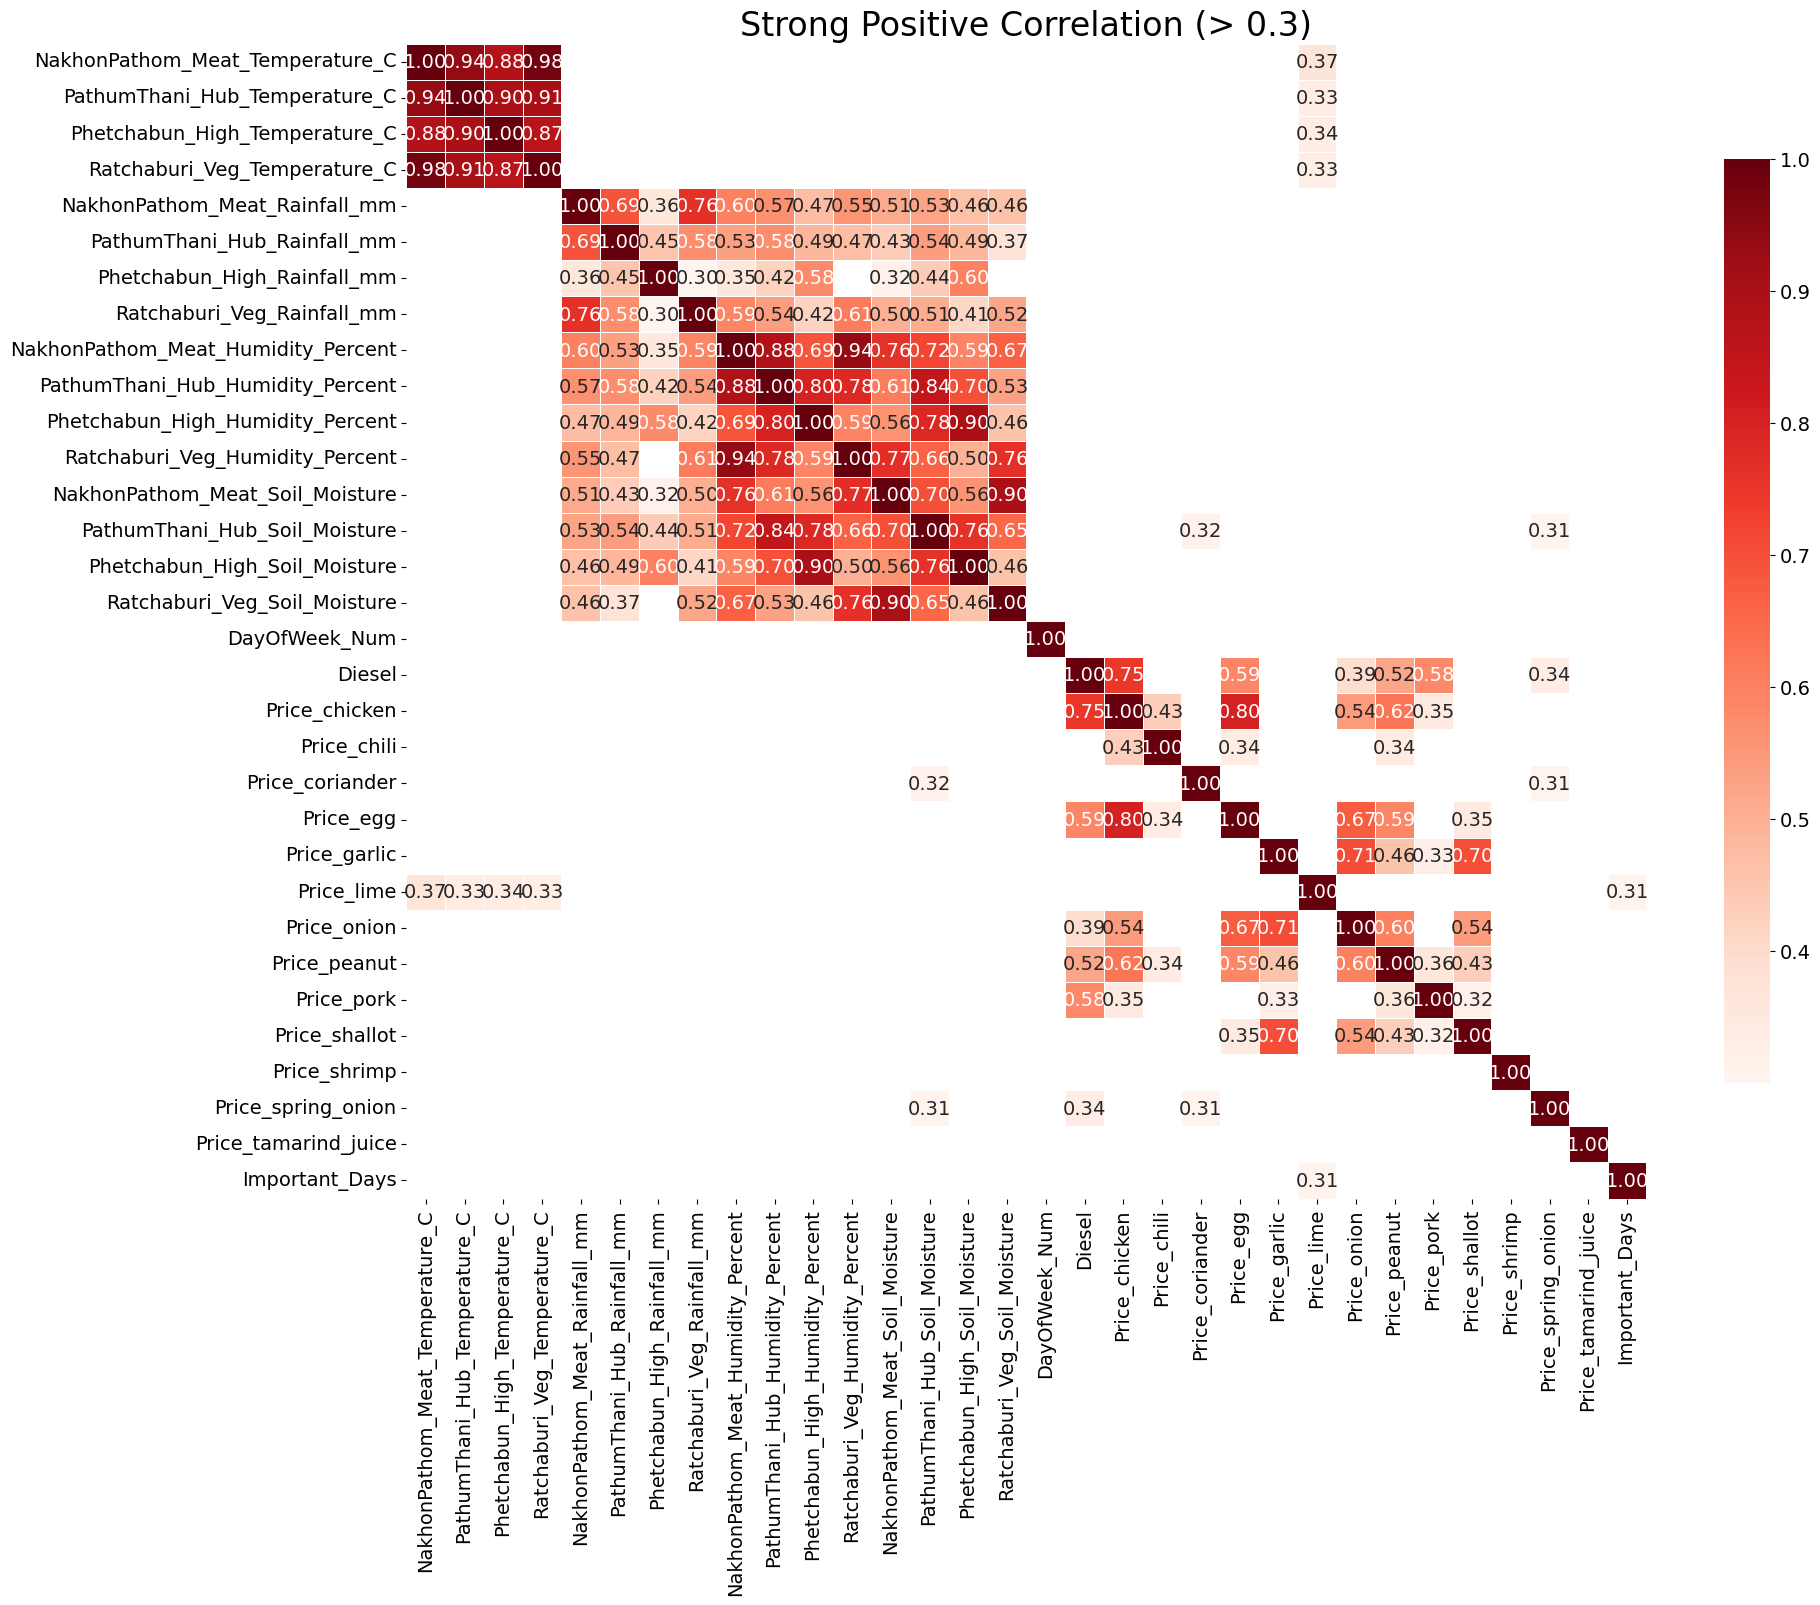

In [10]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 15)) 
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 14

sns.heatmap(corr_matrix, 
            mask=corr_matrix <= 0.3,           
            annot=True,          
            fmt=".2f",           
            cmap='Reds',         
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Strong Positive Correlation (> 0.3)', fontsize=24)
plt.xticks(rotation=90)
plt.show()

In [18]:
corr_matrix.columns

Index(['NakhonPathom_Meat_Temperature_C', 'PathumThani_Hub_Temperature_C',
       'Phetchabun_High_Temperature_C', 'Ratchaburi_Veg_Temperature_C',
       'NakhonPathom_Meat_Rainfall_mm', 'PathumThani_Hub_Rainfall_mm',
       'Phetchabun_High_Rainfall_mm', 'Ratchaburi_Veg_Rainfall_mm',
       'NakhonPathom_Meat_Humidity_Percent',
       'PathumThani_Hub_Humidity_Percent', 'Phetchabun_High_Humidity_Percent',
       'Ratchaburi_Veg_Humidity_Percent', 'NakhonPathom_Meat_Soil_Moisture',
       'PathumThani_Hub_Soil_Moisture', 'Phetchabun_High_Soil_Moisture',
       'Ratchaburi_Veg_Soil_Moisture', 'DayOfWeek_Num', 'Diesel',
       'Price_chicken', 'Price_chili', 'Price_coriander', 'Price_egg',
       'Price_garlic', 'Price_lime', 'Price_onion', 'Price_peanut',
       'Price_pork', 'Price_shallot', 'Price_shrimp', 'Price_spring_onion',
       'Price_tamarind_juice', 'Important_Days'],
      dtype='object')

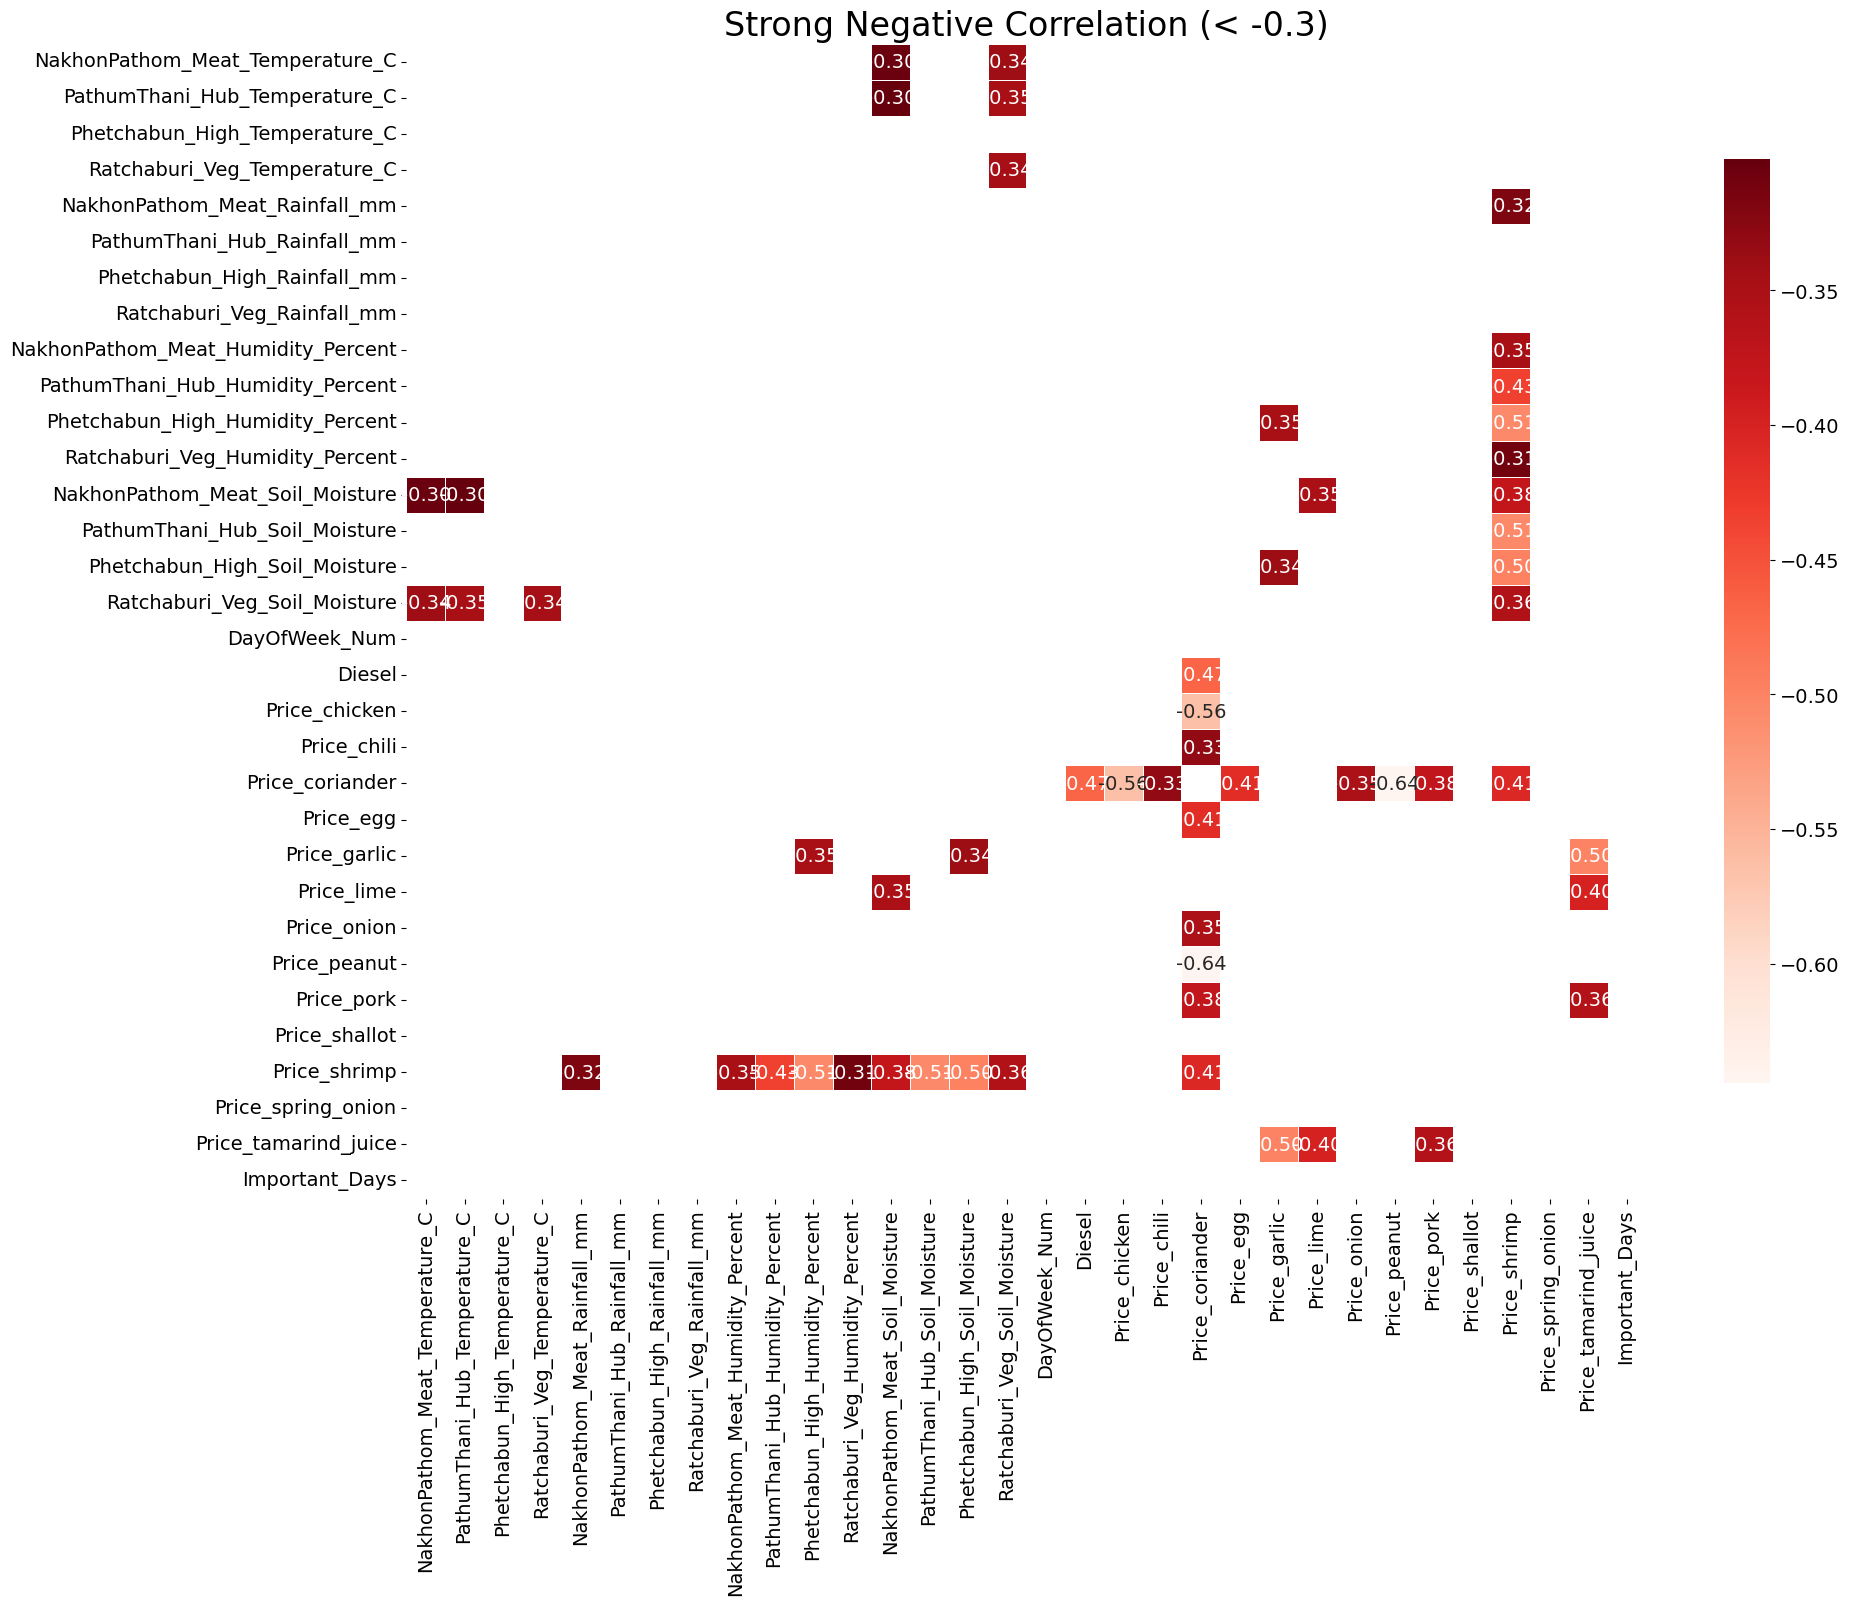

In [16]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 15)) 
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 14

sns.heatmap(corr_matrix, 
            mask=corr_matrix >= -0.3,           
            annot=True,          
            fmt=".2f",           
            cmap='Reds',         
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Strong Negative Correlation (< -0.3)', fontsize=24)
plt.xticks(rotation=90)
plt.show()

In [ ]:
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.2f' % x)

print(df.corr().to_string())

pd.reset_option('display.float_format')

                                    NakhonPathom_Meat_Temperature_C  PathumThani_Hub_Temperature_C  Phetchabun_High_Temperature_C  Ratchaburi_Veg_Temperature_C  NakhonPathom_Meat_Rainfall_mm  PathumThani_Hub_Rainfall_mm  Phetchabun_High_Rainfall_mm  Ratchaburi_Veg_Rainfall_mm  NakhonPathom_Meat_Humidity_Percent  PathumThani_Hub_Humidity_Percent  Phetchabun_High_Humidity_Percent  Ratchaburi_Veg_Humidity_Percent  NakhonPathom_Meat_Soil_Moisture  PathumThani_Hub_Soil_Moisture  Phetchabun_High_Soil_Moisture  Ratchaburi_Veg_Soil_Moisture  DayOfWeek_Num  Diesel  Price_chicken  Price_chili  Price_coriander  Price_egg  Price_garlic  Price_lime  Price_onion  Price_peanut  Price_pork  Price_shallot  Price_shrimp  Price_spring_onion  Price_tamarind_juice  Important_Days
NakhonPathom_Meat_Temperature_C                                1.00                           0.94                           0.88                          0.98                          -0.09                        -0.03           